In [ ]:
#!pip install matplotlib

In [ ]:
#!pip install tensorflow

In [ ]:
#!pip install scikit-learn

In [ ]:
#!pip install plotly

In [1]:
#pip show tensorflow

Name: tensorflow
Version: 2.21.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: C:\Users\usuario\anaconda3\envs\Proyect_final\Lib\site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, termcolor, typing_extensions, wrapt
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import GRU
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt

import plotly.graph_objects as go
import plotly.io as pio

In [6]:
#importación de datos 
csv_file = "global_file_2021-03-15_to_2026-03-14.csv"

In [7]:
#asegurar el índice sea la fecha y esté en formato de fecha
df_global = pd.read_csv(csv_file, parse_dates=["date"], index_col="date")

C:\Users\usuario\AppData\Local\Temp\ipykernel_10368\3149811028.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_global = pd.read_csv(csv_file, parse_dates=["date"], index_col="date")


In [9]:
df_global.tail()

,usd_mxn_fix,cash_bid,cash_offer,3-month_bid,3-month_offer,dec-27_bid,dec-27_offer,dec-28_bid,dec-28_offer,dec-29_bid,...,3-month_price,month-1_price,month-2_price,month-3_price,month-4_price,month-5_price,month-6_price,interpolated_LME,interpolated_MXN,cash_offer_mxn
date,,,,,,,,,,,,,,,,,,,,,
2026-03-22,17.8998,3328.5,3329.0,3287.0,3287.5,2995.0,3000.0,2920.0,2925.0,2880.0,...,3215.0,3254.76,3238.08,3222.96,3203.33,3189.25,3173.75,True,True,59588.4342
2026-03-23,17.7780,3251.0,3251.5,3220.0,3222.0,2973.0,2978.0,2900.0,2905.0,2865.0,...,3199.0,3232.35,3217.45,3205.67,3188.84,3175.34,3160.84,False,False,57805.1670
2026-03-24,17.8047,3242.0,3242.5,3217.0,3218.0,2965.0,2970.0,2873.0,2878.0,2838.0,...,3260.5,3307.66,3286.07,3270.21,3249.50,3235.25,3216.25,False,False,57731.7398
2026-03-25,17.7548,3294.0,3294.5,3245.0,3247.0,2945.0,2950.0,2870.0,2875.0,2838.0,...,3242.5,3292.99,3269.38,3253.47,3228.92,3209.92,3189.92,False,False,58493.1886
2026-03-26,17.7957,3331.5,3332.0,3271.0,3273.0,2900.0,2905.0,2782.0,2787.0,2737.0,...,3269.5,3330.81,3306.06,3285.04,3254.16,3228.75,3205.50,False,False,59295.2724


In [10]:
#filtrar unicamente los datos reales para el LME 
df_global = df_global[df_global["interpolated_LME"] == False]

In [12]:
df_global.tail()

,usd_mxn_fix,cash_bid,cash_offer,3-month_bid,3-month_offer,dec-27_bid,dec-27_offer,dec-28_bid,dec-28_offer,dec-29_bid,...,3-month_price,month-1_price,month-2_price,month-3_price,month-4_price,month-5_price,month-6_price,interpolated_LME,interpolated_MXN,cash_offer_mxn
date,,,,,,,,,,,,,,,,,,,,,
2026-03-20,17.8998,3328.5,3329.0,3287.0,3287.5,2995.0,3000.0,2920.0,2925.0,2880.0,...,3215.0,3254.76,3238.08,3222.96,3203.33,3189.25,3173.75,False,False,59588.4342
2026-03-23,17.7780,3251.0,3251.5,3220.0,3222.0,2973.0,2978.0,2900.0,2905.0,2865.0,...,3199.0,3232.35,3217.45,3205.67,3188.84,3175.34,3160.84,False,False,57805.1670
2026-03-24,17.8047,3242.0,3242.5,3217.0,3218.0,2965.0,2970.0,2873.0,2878.0,2838.0,...,3260.5,3307.66,3286.07,3270.21,3249.50,3235.25,3216.25,False,False,57731.7398
2026-03-25,17.7548,3294.0,3294.5,3245.0,3247.0,2945.0,2950.0,2870.0,2875.0,2838.0,...,3242.5,3292.99,3269.38,3253.47,3228.92,3209.92,3189.92,False,False,58493.1886
2026-03-26,17.7957,3331.5,3332.0,3271.0,3273.0,2900.0,2905.0,2782.0,2787.0,2737.0,...,3269.5,3330.81,3306.06,3285.04,3254.16,3228.75,3205.50,False,False,59295.2724


In [13]:
# Eliminar columnas no numéricas
df_numeric = df_global.select_dtypes(include=['float64', 'int64'])
# Matriz de correlación
corr_matrix = df_numeric.corr()

In [19]:
# Mostrar correlación con la variable objetivo
target_corr = corr_matrix['cash_offer'].sort_values(ascending=False)
print("Correlación con cash_offer:")
print(target_corr)

Correlación con cash_offer:
cash_offer        1.000000
cash_bid          0.999999
3-month_bid       0.998142
3-month_offer     0.998130
month-1_price     0.996623
month-2_price     0.996260
month-3_price     0.995791
3-month_price     0.995584
month-4_price     0.995078
month-5_price     0.994163
month-6_price     0.993053
dec-27_bid        0.942510
dec-27_offer      0.941705
cash_offer_mxn    0.916490
dec-28_bid        0.775416
dec-28_offer      0.773897
dec-29_bid        0.456344
dec-29_offer      0.455360
usd_mxn_fix       0.307722
Name: cash_offer, dtype: float64


In [5]:
#Selección de variables de entrada del modelo
features = [
    "cash_offer",
    "3-month_price"
]

df_global = df_global[features].copy()

In [6]:
#seleccionar unicamente 1260 datos (número facilmente divisible)
df_global = df_global[features].copy().iloc[-1260:]

In [7]:
df_global.tail()

,cash_offer,3-month_price
date,,
2026-03-16,3440.0,3395.5
2026-03-17,3426.0,3399.5
2026-03-18,3400.0,3400.0
2026-03-19,3200.0,3252.0
2026-03-20,3329.0,3215.0


In [9]:
df_global.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1260 entries, 2021-03-25 to 2026-03-20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   cash_offer     1260 non-null   float64
 1   3-month_price  1260 non-null   float64
dtypes: float64(2)
memory usage: 29.5 KB


In [10]:
#Normalización de datos con MinMaxScaler
scaler = MinMaxScaler()

# Separar en datos de entrenamiento: train y de prueba: test 
split = int(len(df_global) * 0.8)

x_train = df_global.iloc[:split]
x_test = df_global.iloc[split:]

# Ajustar solo con datos de entrenamiento
scaler.fit(x_train)

#escalar todos los datos 
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

In [12]:
print(f"número de datos :{len(df_global)}")
print(f"número de datos de entrenamiento :{len(x_train)}")
print(f"número de datos de prueba :{len(x_test)}")

número de datos :1260
número de datos de entrenamiento :1008
número de datos de prueba :252


In [15]:
#Parametros red neuronal
window = 63 
batch_size = 21
epochs = 50
learning_rate = 0.001
seed = 1

In [17]:
#generación de la serie de ventanas para cada conjunto de datos

dataset_train = tf.keras.utils.timeseries_dataset_from_array(
    data=x_train,
    targets=x_train[window:, 0],  # columna 0 = cash offer 
    sequence_length=window,
    batch_size=batch_size,
    shuffle=False
)

dataset_test = tf.keras.utils.timeseries_dataset_from_array(
    data=x_test,
    targets=x_test[window:, 0],
    sequence_length=window,
    batch_size=batch_size,
    shuffle=False
)

In [18]:
for x, y in dataset_train:
    print(x.shape, y.shape)
    break

(21, 63, 2) (21,)


In [19]:
for x, y in dataset_test:
    print(x.shape, y.shape)
    break

(21, 63, 2) (21,)


In [20]:
n_features = x_train.shape[1]
n_features

2

In [64]:
tf.random.set_seed(seed) 

model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(window, n_features)))
model.add(Dropout(0.2))
model.add(GRU(64, return_sequences=True))
model.add(GRU(32))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

In [66]:
optimizer = Adam(learning_rate=learning_rate)

early_stopping = EarlyStopping(
    monitor='val_loss', #se selecciona validación para ver como responde realmente el modelo con datos desconocidos 
    patience=10, #se selecciona 10 para poder observar que está pasando cuando deja de mejorar el modelo
    restore_best_weights=True
)

model.compile(
    loss='mean_squared_error',
    optimizer=optimizer
)

In [67]:
history = model.fit(
    dataset_train,
    validation_data=dataset_test,
    epochs=epochs,
    callbacks=[early_stopping]
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 177ms/step - loss: 0.0088 - val_loss: 0.0030
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 172ms/step - loss: 0.0046 - val_loss: 0.0035
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - loss: 0.0044 - val_loss: 0.0045
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 159ms/step - loss: 0.0049 - val_loss: 0.0044
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - loss: 0.0059 - val_loss: 0.0088
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 157ms/step - loss: 0.0054 - val_loss: 0.0063
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 164ms/step - loss: 0.0058 - val_loss: 0.0060
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 153ms/step - loss: 0.0058 - val_loss: 0.0092
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 163ms/step - loss: 0.0056 - val_loss: 0.0143
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 158ms/step - loss: 0.0059 - val_loss: 0.0098
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 163ms/step - loss: 0.0065 - val_loss: 0.0024
Epoch 12/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 181ms/ste

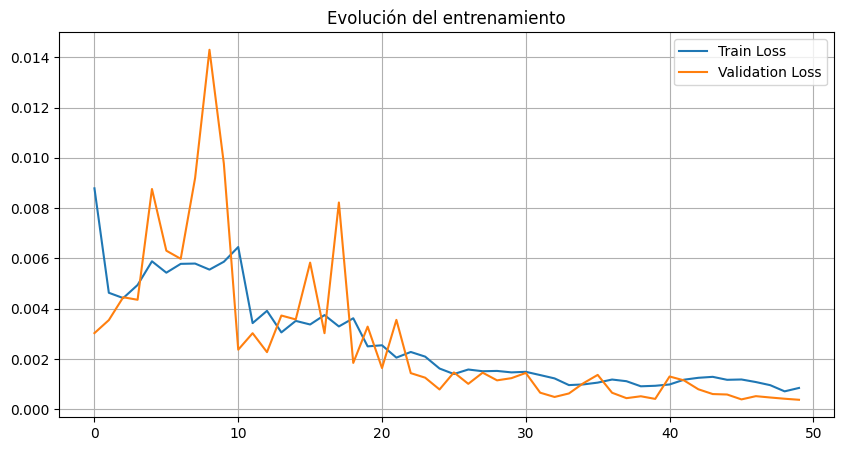

In [68]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.grid()
plt.title("Evolución del entrenamiento")
plt.show()

In [69]:
#Devolución de datos predichos para los dos segmentos entrenamiento y prueba 
y_hat_train = model.predict(dataset_train).flatten()
y_hat_test = model.predict(dataset_test).flatten()

45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [70]:
print(f"número de datos calculados (entrenamiento) :{len(y_hat_train)}")
print(f"número de datos calculados (prueba) :{len(y_hat_test)}")

número de datos calculados (entrenamiento) :945
número de datos calculados (prueba) :189


In [71]:
#Conversión de los datos calculados(desescalamiento) 
def inverse_transform_predictions(y_pred, scaler, n_features):
    dummy = np.zeros((len(y_pred), n_features))
    dummy[:, 0] = y_pred
    return scaler.inverse_transform(dummy)[:, 0]

y_hat_train = inverse_transform_predictions(y_hat_train, scaler, n_features)
y_hat_test = inverse_transform_predictions(y_hat_test, scaler, n_features)

In [72]:
#Conversión de los datos reales(desescalamiento) 
y_train_real_scaled = x_train[window:, 0]
y_test_real_scaled = x_test[window:, 0]

def inverse_transform_real(y_real_scaled, scaler, n_features):
    dummy = np.zeros((len(y_real_scaled), n_features))
    dummy[:, 0] = y_real_scaled
    return scaler.inverse_transform(dummy)[:, 0]

y_train_real = inverse_transform_real(y_train_real_scaled, scaler, n_features)
y_test_real = inverse_transform_real(y_test_real_scaled, scaler, n_features)

In [73]:
print(f"número de datos reales (entrenamiento) :{len(y_train_real)}")
print(f"número de datos reales (prueba) :{len(y_test_real)}")

número de datos reales (entrenamiento) :945
número de datos reales (prueba) :189


In [74]:
# Ajustar tamaños a predicciones para asegurar coincidencia al momento de graficar
y_train_real = y_train_real[-len(y_hat_train):]
y_test_real = y_test_real[-len(y_hat_test):]

train_index = df_global.index[:split]
test_index = df_global.index[split:]

x_plot_train = train_index[-len(y_hat_train):]
x_plot_test = test_index[-len(y_hat_test):]

In [75]:
#plt.figure(figsize=(15, 8))

#plt.plot(df_global.index, df_global["cash_offer"], label="Real")
#plt.plot(x_plot_train, y_hat_train, label="Train Pred")
#plt.plot(x_plot_test, y_hat_test, label="Test Pred")

#plt.legend()
#plt.grid()
#plt.show()

In [76]:

pio.renderers.default = "iframe"

fig = go.Figure()

# Real
fig.add_trace(go.Scatter(
    x=df_global.index,
    y=df_global["cash_offer"],
    mode='lines',
    name='Real'
))

# Train
fig.add_trace(go.Scatter(
    x=x_plot_train,
    y=y_hat_train,
    mode='lines',
    name='Train Pred'
))

# Test
fig.add_trace(go.Scatter(
    x=x_plot_test,
    y=y_hat_test,
    mode='lines',
    name='Test Pred'
))

fig.update_layout(
    title="Predicción vs Real",
    xaxis_title="Fecha",
    yaxis_title="Precio",
    hovermode="x unified"  # 🔥 clave para comparar en el mismo punto
)

fig.show()

In [78]:
#Cálculo del error absoluto medio para los datos de entrenamiento y prueba 
mae_train = mean_absolute_error(y_train_real, y_hat_train)
mae_test = mean_absolute_error(y_test_real, y_hat_test)

print("MAE Train:", mae_train)
print("MAE Test:", mae_test)

MAE Train: 42.93729854281302
MAE Test: 25.248826898595013


In [79]:
#generación de un df con los resultados del modeolo y su comparación con los datos reales
# datos de entreamiento
df_results_train = pd.DataFrame({
    "fecha": x_plot_train,
    "real": y_train_real,
    "pred": y_hat_train
})

df_results_train["set"] = "train"


# datos de prueba 
df_results_test = pd.DataFrame({
    "fecha": x_plot_test,
    "real": y_test_real,
    "pred": y_hat_test
})

df_results_test["set"] = "test"


#unión de ambos df 
df_results = pd.concat([df_results_train, df_results_test])


# Cálculo del error absoluto y error porcentual
df_results["error"] = df_results["real"] - df_results["pred"]
df_results["error_pct"] = df_results["error"] / df_results["real"] * 100


df_results = df_results.set_index("fecha").sort_index()
df_results.tail()

,real,pred,set,error,error_pct
fecha,,,,,
2026-03-16,3440.0,3469.127189,test,-29.127189,-0.846721
2026-03-17,3426.0,3414.606688,test,11.393312,0.332554
2026-03-18,3400.0,3389.593485,test,10.406515,0.306074
2026-03-19,3200.0,3376.641209,test,-176.641209,-5.520038
2026-03-20,3329.0,3255.625731,test,73.374269,2.204093


In [80]:
df_results.groupby("set")["error"].mean()

set
test      0.542714
train   -23.346190
Name: error, dtype: float64

In [81]:
model.save("modelo_lstm3.keras")